# Systems Biology Project 3: Spatial Proteomics

## Useful code snippets from moodle

In [1]:
import anndata as ad, squidpy as sq, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.spatial import KDTree
from scipy.stats import zscore
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

/Users/zofiarewak/miniconda3/envs/gilda_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/zofiarewak/miniconda3/envs/gilda_env/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/zofiarewak/miniconda3/envs/gilda_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

## Task 1- Dataset overview

In [2]:
adata = ad.read_h5ad('data/train_adata.h5ad')
adata.layers['exprs_arcsinh'] = adata.layers['exprs'] # already arcsinh(x/5)

In [3]:
n_cells = adata.n_obs
n_markers = adata.n_vars
n_images = adata.obs["image"].nunique()
n_indications = adata.obs["Indication"].nunique()
overview_df = pd.DataFrame({
    "Property": [
        "number of cells",
        "number of markers",
        "number of images",
        "number of cancer indications"
    ],
    "Value": [
        n_cells,
        n_markers,
        n_images,
        n_indications
    ]
})
overview_df

,Property,Value
0,number of cells,253433
1,number of markers,40
2,number of images,132
3,number of cancer indications,5


In [4]:
celltype_counts = (
    adata.obs["celltypes"]
    .value_counts()
    .reset_index()
)

celltype_counts.columns = ["Cell type", "Cell count"]

celltype_counts

,Cell type,Cell count
0,Tumor,138266
1,CD8,22722
2,Mural,20537
3,MacCD163,15288
4,CD4,13238
5,plasma,7872
6,Neutrophil,7386
7,BnT,6493
8,Treg,6381
9,DC,4921


In [5]:
tumor_fraction = (
    (adata.obs["celltypes"] == "Tumor").mean() * 100
)
print(f"Tumor fraction: {tumor_fraction:.1f}%")

Tumor fraction: 54.6%


In [6]:
display(overview_df)
display(celltype_counts)
print(f"\nTumor fraction: {tumor_fraction:.1f}%")

,Property,Value
0,number of cells,253433
1,number of markers,40
2,number of images,132
3,number of cancer indications,5


,Cell type,Cell count
0,Tumor,138266
1,CD8,22722
2,Mural,20537
3,MacCD163,15288
4,CD4,13238
5,plasma,7872
6,Neutrophil,7386
7,BnT,6493
8,Treg,6381
9,DC,4921



Tumor fraction: 54.6%


## Task 2

In [7]:
adata.var.head()
# chosing 3 markers: Ecad, CD8a, Ki67
markers = ["Ecad", "CD8a", "Ki67"]
marker_expr = {}
for marker in markers:
    col = np.where(adata.var["marker"] == marker)[0][0]
    expr = adata.layers["exprs_arcsinh"][:, col]
    marker_expr[marker] = expr

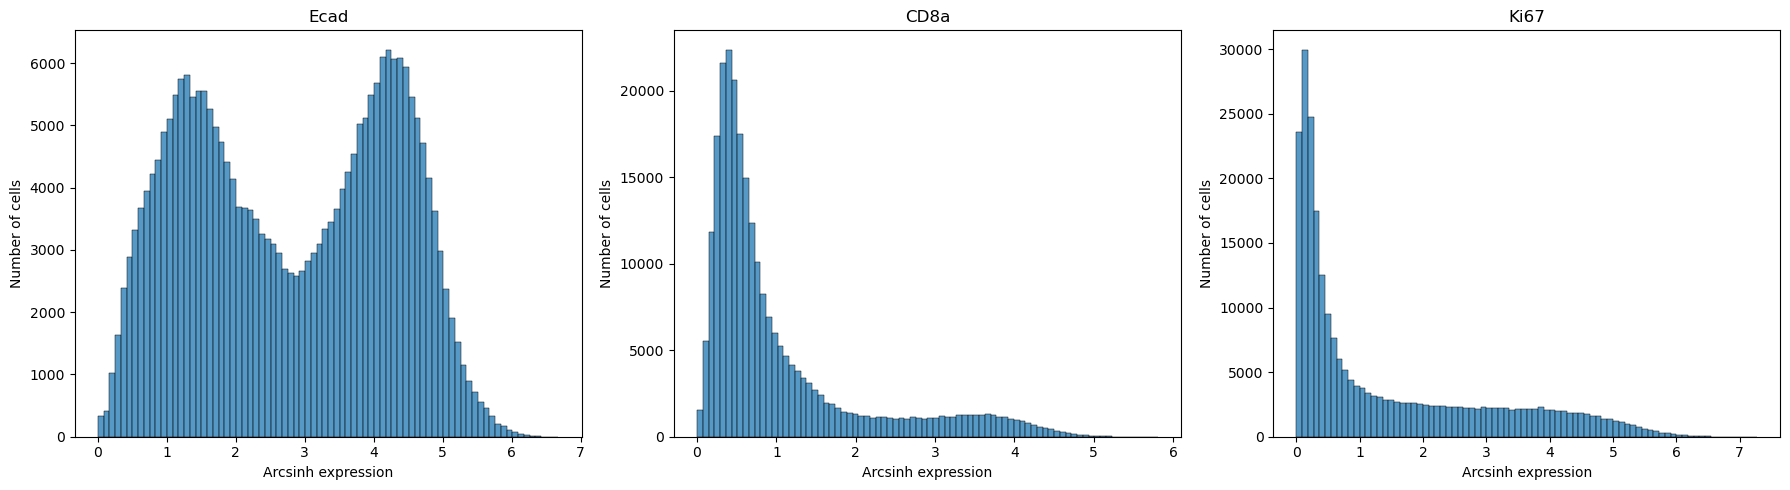

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, marker in zip(axes, markers):
    
    sns.histplot(
        marker_expr[marker],
        bins=80,
        ax=ax
    )
    ax.set_title(marker)
    ax.set_xlabel("Arcsinh expression")
    ax.set_ylabel("Number of cells")

plt.tight_layout()
plt.show()

### Annotation
`Ecad`: This marker shows bimodal distribution 

`CD8a`: This marker shows unimodal distribution 

`Ki67`: This marker shows unimodal distribution 

## Task 3

In [9]:
tumor_fraction = (
    adata.obs
    .assign(is_tumor = adata.obs["celltypes"] == "Tumor")
    .groupby("Indication", observed=True)["is_tumor"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
tumor_fraction

Indication
HN       67.878176
GI       53.566986
THOR     53.193929
BREAS    51.613859
GU       45.555810
Name: is_tumor, dtype: float64

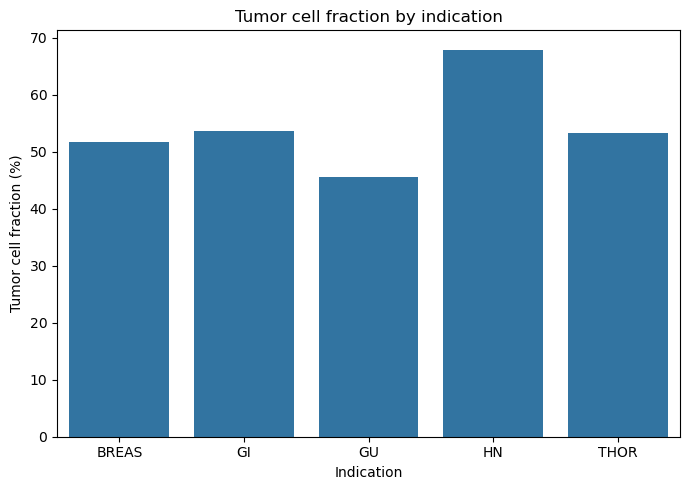

In [10]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=tumor_fraction.index,
    y=tumor_fraction.values
)

plt.ylabel("Tumor cell fraction (%)")
plt.xlabel("Indication")
plt.title("Tumor cell fraction by indication")

plt.tight_layout()
plt.show()

In [11]:
tumor_adata = adata[
    adata.obs["celltypes"] == "Tumor"
].copy()
markers = [
    "Ecad",
    "CarbonicAnhydrase",
    "Ki67"
]
marker_cols = {
    marker: np.where(tumor_adata.var["marker"] == marker)[0][0]
    for marker in markers
}

marker_cols

{'Ecad': np.int64(34), 'CarbonicAnhydrase': np.int64(27), 'Ki67': np.int64(29)}

The `tumor fraction` dataframe shows, that tissue with `HN` marker has the strongest tumor fraction. GU exhibits the lowest tumor fraction indicating a smaller contribution of cancer cells to the tumor microenviroment 

In [12]:
marker_df = pd.DataFrame(index=tumor_adata.obs["Indication"].unique())
for marker, col in marker_cols.items():

    expr = tumor_adata.layers["exprs_arcsinh"][:, col]

    tmp = pd.DataFrame({
        "Indication": tumor_adata.obs["Indication"].values,
        marker: expr
    })

    marker_df[marker] = (
        tmp.groupby("Indication", observed=True)[marker]
        .mean()
    )

marker_df

,Ecad,CarbonicAnhydrase,Ki67
THOR,3.474983,1.451339,1.916187
HN,4.321932,2.436929,2.535008
GU,1.495726,3.894414,0.389315
GI,3.863488,1.557918,2.169100
BREAS,4.335988,1.909136,2.231839


In [13]:
zdf = pd.DataFrame(
    zscore(marker_df.values, axis=0),
    index=marker_df.index,
    columns=marker_df.columns
)

zdf

,Ecad,CarbonicAnhydrase,Ki67
THOR,-0.022300,-0.896005,0.089857
HN,0.783455,0.209786,0.908811
GU,-1.905293,1.845024,-1.930824
GI,0.347309,-0.776428,0.424564
BREAS,0.796828,-0.382376,0.507593


In [14]:
linkage_matrix = linkage(
    marker_df,
    method="ward"
)

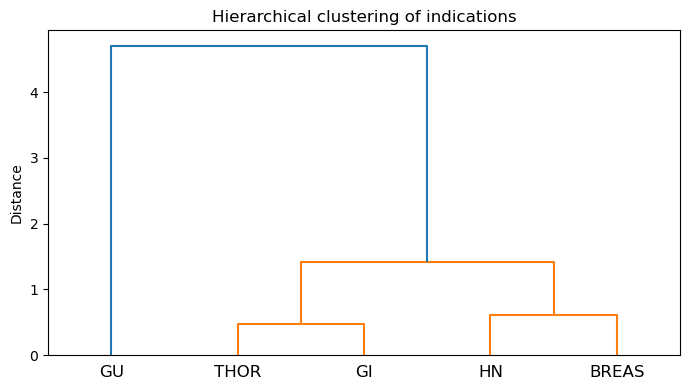

In [15]:
plt.figure(figsize=(7,4))

dendrogram(
    linkage_matrix,
    labels=marker_df.index.tolist()
)

plt.title("Hierarchical clustering of indications")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

### Annotation 
The plot indicates, that `GU` clusters separately, while `THOR` and `GI` cluster together and `HN` clusters with `BREAS`. 

The shared clustering patterns suggest that `THOR` and `GI` tumours may exhibit similar epithelial and proliferative characteristics, whereas the distinct separation of `GU` may reflect differences in metabolic adaptation or tumour microenvironment composition.

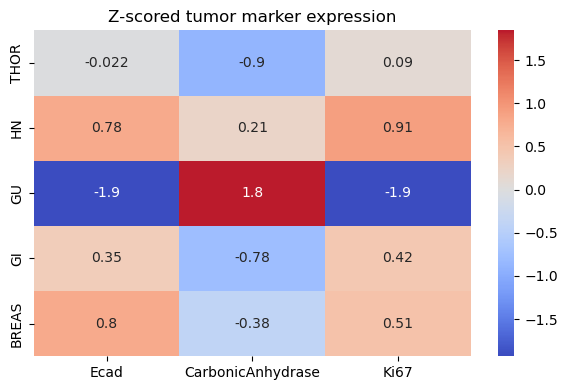

In [16]:
plt.figure(figsize=(6,4))

sns.heatmap(
    zdf,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Z-scored tumor marker expression")

plt.tight_layout()
plt.show()

## Task 4

In [17]:
image_stats = (
    adata.obs
    .groupby(["image", "celltypes"], observed=True)
    .size()
    .unstack(fill_value=0)
)

In [18]:
# filtering, so there are at least 100 tumor cells  
filtered = image_stats[
    image_stats["Tumor"] >= 100
].copy()
filtered["CD8_Tumor_ratio"] = (
    filtered["CD8"] / filtered["Tumor"]
)

In [19]:
top_image = filtered["CD8_Tumor_ratio"].idxmax()
top_value = filtered.loc[top_image, "CD8_Tumor_ratio"]

print("Selected image:", top_image)
print("CD8/Tumor ratio:", top_value)

Selected image: IMMUcan_Batch20210701_10075013-SPECT-VAR-TIS-UNST-03_002.tiff
CD8/Tumor ratio: 2.613756613756614


In [20]:
img = adata[adata.obs["image"] == top_image].copy()

In [21]:
marker = "Ki67"

col = np.where(img.var["marker"] == marker)[0][0]

expr = img.layers["exprs_arcsinh"][:, col]

#5-95 % clipping
vmin, vmax = np.percentile(expr, [5, 95])

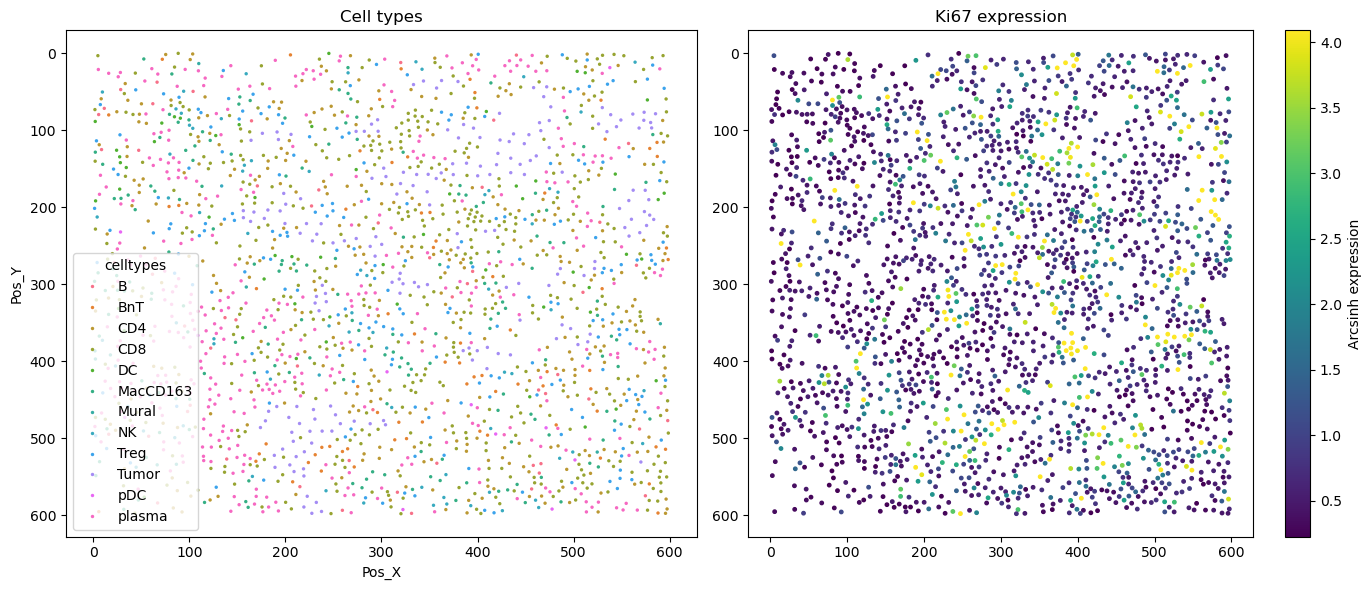

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# cell types
sns.scatterplot(
    data=img.obs,
    x="Pos_X",
    y="Pos_Y",
    hue="celltypes",
    s=6,
    linewidth=0,
    ax=axes[0]
)

axes[0].set_title("Cell types")
axes[0].invert_yaxis()

# marker
sc = axes[1].scatter(
    img.obs["Pos_X"],
    img.obs["Pos_Y"],
    c=expr,
    cmap="viridis",
    s=6,
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title(f"{marker} expression")
axes[1].invert_yaxis()

cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label("Arcsinh expression")

plt.tight_layout()
plt.show()

### Annotation
Images with fewer than 100 Tumor cells were excluded. The image with the highest CD8/Tumor ratio is IMMUcan_Batch20210701_10075013-SPECT-VAR-TIS-UNST-03_002.tiff with a value of 2.613756613756614. This indicates, that `CD8` lymphocytes actively fight with the tumor cells, because `CD8` cells dominate in the microenviroment. 

In [23]:
adata_s = adata[adata.obs["image"] == top_image].copy()
adata_s.obsm["spatial"] = np.column_stack([adata_s.obs["Pos_X"].values,adata_s.obs["Pos_Y"].values])

In [24]:
sq.gr.spatial_neighbors(adata_s, coord_type='generic', spatial_key='spatial', n_neighs=10)
adata_s.uns.keys()

odict_keys(['spatial_neighbors'])

In [40]:
sq.gr.nhood_enrichment(
    adata_s,
    cluster_key="celltypes", 
)

  0%|          | 0/1000 [00:00<?, ?/s]

/Users/zofiarewak/miniconda3/envs/gilda_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/zofiarewak/miniconda3/envs/gilda_env/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/zofiarewak/miniconda3/envs/gilda_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

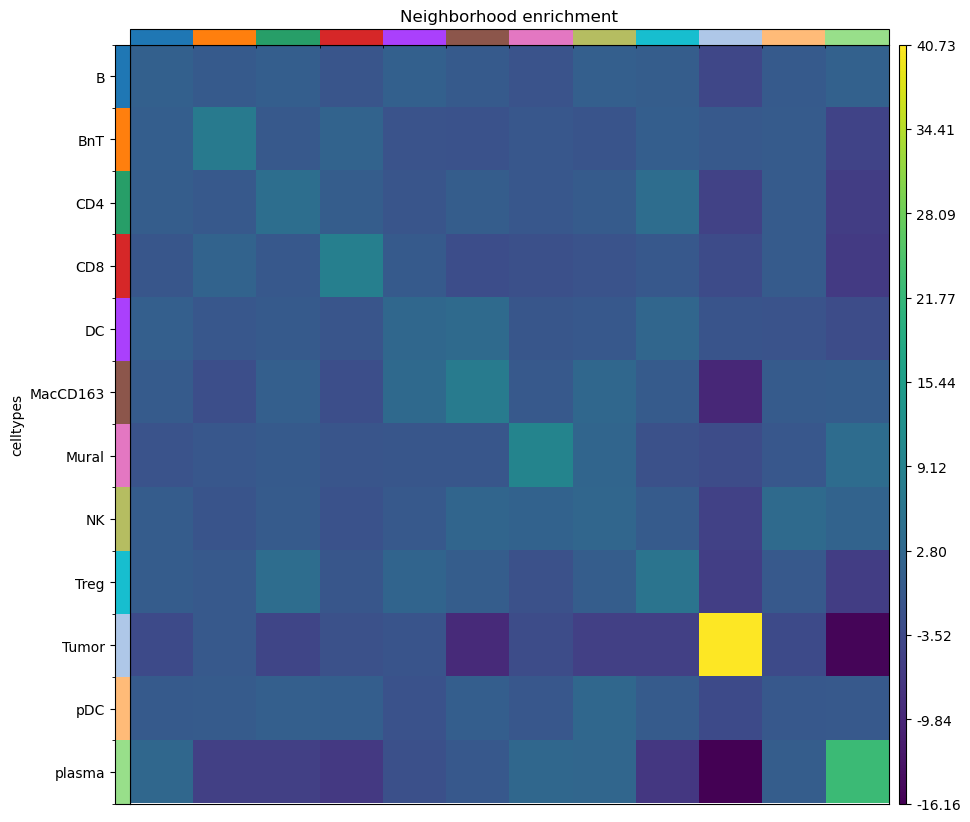

In [43]:
sq.pl.nhood_enrichment(
    adata_s,
    cluster_key="celltypes"
)

plt.show()

In [44]:
z = adata_s.uns["celltypes_nhood_enrichment"]["zscore"]

z_df = pd.DataFrame(
    z,
    index=adata_s.obs["celltypes"].cat.categories,
    columns=adata_s.obs["celltypes"].cat.categories
)

In [45]:
tumor_row = z_df.loc["Tumor"].drop("Tumor")

top2 = tumor_row.sort_values(ascending=False).head(2)

top2

BnT   -0.171308
DC    -1.438988
Name: Tumor, dtype: float64

In [46]:
tumor_self = z_df.loc["Tumor", "Tumor"]
tumor_self

np.float64(40.72688253489984)

In [47]:
cd8_score = z_df.loc["Tumor", "CD8"]
cd8_score

np.float64(-1.9598880379752168)

In [48]:
adata_s.uns.keys()

odict_keys(['spatial_neighbors', 'celltypes_nhood_enrichment'])